# Quantum Fourier Transform
The QFT is the quantum Discrete Fourier Transform: $QFT|x\rangle=\frac{1}{\sqrt{N}}\sum_y e^{2\pi i xy/N}|y\rangle$.
To *see* it work we use it as a frequency detector — feed in a plane wave that oscillates at frequency $f$ across the register,
and the QFT concentrates all that amplitude onto the single basis state $|f\rangle$, exactly like a classical DFT turning a sine wave into one spike.
Same setup as before: real backend and a noise-matched simulator, in parallel.

In [1]:
# Connect to IBM Quantum (account already saved earlier)
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

In [2]:
# Pick the real backend and build a Sampler bound to it
from qiskit_ibm_runtime import SamplerV2 as Sampler

backend = service.backend("ibm_marrakesh")
sampler = Sampler(mode=backend)
print(backend.name)

ibm_marrakesh


In [3]:
# Build a local Aer simulator that mimics the backend's noise
from qiskit.primitives import BackendSamplerV2
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

noise_model = NoiseModel.from_backend(backend)
backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)

In [4]:
# QFT circuit: Hadamard + controlled phase rotations per qubit, then reverse the qubit order
from math import pi
from qiskit import QuantumCircuit

def qft(n: int) -> QuantumCircuit:
    qc = QuantumCircuit(n)
    def rotations(k):
        if k == 0:
            return
        k -= 1
        qc.h(k)
        for q in range(k):
            qc.cp(pi / 2 ** (k - q), q, k)   # phase kick from lower qubits
        rotations(k)
    rotations(n)
    for i in range(n // 2):
        qc.swap(i, n - 1 - i)                # QFT outputs bits in reversed order
    return qc

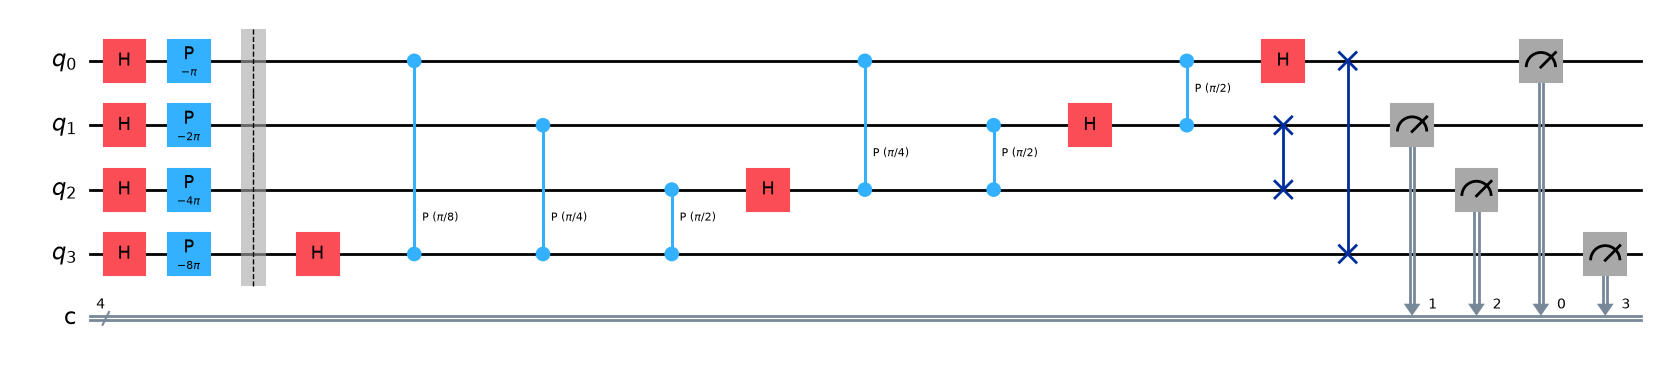

In [16]:
# Prepare a plane wave of frequency f, then apply the QFT to read the frequency back
f = 8                                        # the frequency we expect to recover
n = 4
N = 2 ** n

qc = QuantumCircuit(n, n)
qc.h(range(n))                               # flat superposition over all x
for j in range(n):
    qc.p(-2 * pi * f * (2 ** j) / N, j)      # imprint phases -> plane wave e^{-2πi f x / N}
qc.barrier()
qc.compose(qft(n), inplace=True)             # QFT collapses the wave onto |f>
qc.measure(range(n), range(n))

qc.draw("mpl")

In [10]:
# Transpile to the backend's native gates/qubits (ISA circuit)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(target=backend.target, optimization_level=3)
qc_isa = pm.run(qc)

In [11]:
# Submit both jobs first so they run in parallel, then collect results
job_real = sampler.run([qc_isa], shots=1024)
job_sim = sampler_sim.run([qc_isa], shots=1024)

counts_real = job_real.result()[0].data.c.get_counts()
counts_sim = job_sim.result()[0].data.c.get_counts()

frequency f : 8
sim  peak   : 1000 = 8
real peak   : 1000 = 8


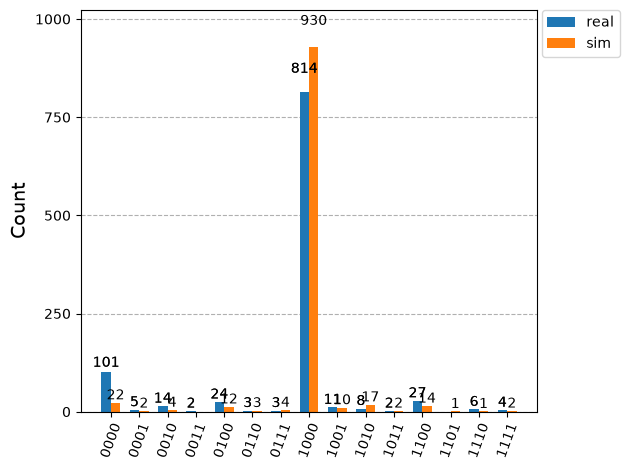

In [12]:
# The dominant bitstring, read as an integer, should equal f
from qiskit.visualization import plot_histogram

peak_sim = max(counts_sim, key=counts_sim.get)
peak_real = max(counts_real, key=counts_real.get)
print("frequency f :", f)
print("sim  peak   :", peak_sim, "=", int(peak_sim, 2))
print("real peak   :", peak_real, "=", int(peak_real, 2))
plot_histogram([counts_real, counts_sim], legend=["real", "sim"])

## What the results mean

**The single peak at `0101` (= 5).** We built an input whose amplitudes rotate through the register at frequency `f = 5` — a quantum plane wave, the direct analogue of a classical sine wave sampled at 16 points. The QFT is a change of basis from the *computational* basis (positions) to the *frequency* basis. A pure wave of one frequency has all its weight at that single frequency, so after the QFT the interference is fully constructive on `|5⟩` and fully destructive everywhere else. Measuring therefore returns `0101` almost every time. If you change `f` in the prep cell, the peak moves to match.

**Why this matters more than it looks.** The QFT itself doesn't "solve" anything here — it's a subroutine. But this exact move (encode information into phases, then QFT to turn those phases into a readable number) is the beating heart of Quantum Phase Estimation, and through it, Shor's factoring algorithm. Everything in Phase 2 and 3 of the roadmap is built on the pattern you're seeing in this one histogram.

**Real vs. sim.** On the noiseless math the peak would be 100%. On hardware you'll see a tall bar at `0101` plus a spread of smaller bars — the QFT uses controlled-phase gates between qubits, and after transpilation those become chains of two-qubit gates, which are the noisiest operation on the device. The width of that spread is a direct, visual measure of how much accumulated gate error your circuit picked up; the noise-matched simulator should predict roughly the same spread. If the real peak still lands on `0101`, the signal survived the noise; if a neighbor like `0100` or `0110` occasionally wins, that's phase error nudging the estimate by one — exactly the failure mode phase estimation has to guard against.